In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
students = pd.read_csv('../data/students.csv')
placements = pd.read_csv('../data/placements.csv')
attendence = pd.read_csv('../data/attendence.csv')

## Basic Info

In [13]:
students.head()

,StudentID,Name,Gender,Age,Branch,Marks,City
0,101,Krishna,M,20,CSE,89,Delhi
1,102,Rahul,M,21,CSE,76,Mumbai
2,103,Priya,F,20,IT,92,Pune
3,104,Anjali,F,22,ECE,85,Delhi
4,105,Aman,M,21,IT,78,Jaipur


In [14]:
students.tail()

,StudentID,Name,Gender,Age,Branch,Marks,City
5,106,Riya,F,20,CSE,95,Mumbai
6,107,Arjun,M,22,ECE,67,Delhi
7,108,Sneha,F,21,IT,88,Pune
8,109,Karan,M,20,CSE,81,Mumbai
9,110,Neha,F,22,ECE,90,Jaipur


In [15]:
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   StudentID  10 non-null     int64
 1   Name       10 non-null     str  
 2   Gender     10 non-null     str  
 3   Age        10 non-null     int64
 4   Branch     10 non-null     str  
 5   Marks      10 non-null     int64
 6   City       10 non-null     str  
dtypes: int64(3), str(4)
memory usage: 692.0 bytes


In [16]:
students.describe()

,StudentID,Age,Marks
count,10.00000,10.000000,10.000000
mean,105.50000,20.900000,84.100000
std,3.02765,0.875595,8.569325
min,101.00000,20.000000,67.000000
25%,103.25000,20.000000,78.750000
50%,105.50000,21.000000,86.500000
75%,107.75000,21.750000,89.750000
max,110.00000,22.000000,95.000000


In [17]:
students.shape

(10, 7)

In [18]:
students.columns

Index(['StudentID', 'Name', 'Gender', 'Age', 'Branch', 'Marks', 'City'], dtype='str')

## Data Cleaning

In [20]:
students.isnull().sum()

StudentID    0
Name         0
Gender       0
Age          0
Branch       0
Marks        0
City         0
dtype: int64

In [23]:
students.duplicated().sum()

np.int64(0)

In [24]:
students.drop_duplicates(inplace=True)

In [25]:
def grade(marks):
    if marks >= 90:
        return "A"
    elif marks >= 80:
        return "B"
    elif marks >= 70:
        return "C"
    else:
        return "D"
students['Grade'] = students['Marks'].apply(grade)

In [26]:
students.head()

,StudentID,Name,Gender,Age,Branch,Marks,City,Grade
0,101,Krishna,M,20,CSE,89,Delhi,B
1,102,Rahul,M,21,CSE,76,Mumbai,C
2,103,Priya,F,20,IT,92,Pune,A
3,104,Anjali,F,22,ECE,85,Delhi,B
4,105,Aman,M,21,IT,78,Jaipur,C


In [28]:
students[students['Marks'] > 85]

,StudentID,Name,Gender,Age,Branch,Marks,City,Grade
0,101,Krishna,M,20,CSE,89,Delhi,B
2,103,Priya,F,20,IT,92,Pune,A
5,106,Riya,F,20,CSE,95,Mumbai,A
7,108,Sneha,F,21,IT,88,Pune,B
9,110,Neha,F,22,ECE,90,Jaipur,A


In [29]:
students[students['Gender'] == 'F']

,StudentID,Name,Gender,Age,Branch,Marks,City,Grade
2,103,Priya,F,20,IT,92,Pune,A
3,104,Anjali,F,22,ECE,85,Delhi,B
5,106,Riya,F,20,CSE,95,Mumbai,A
7,108,Sneha,F,21,IT,88,Pune,B
9,110,Neha,F,22,ECE,90,Jaipur,A


In [30]:
students[(students['Marks'] > 80) & (students['Branch'] == 'CSE')]

,StudentID,Name,Gender,Age,Branch,Marks,City,Grade
0,101,Krishna,M,20,CSE,89,Delhi,B
5,106,Riya,F,20,CSE,95,Mumbai,A
8,109,Karan,M,20,CSE,81,Mumbai,B


In [31]:
students.groupby('Branch')['Marks'].mean()

Branch
CSE    85.250000
ECE    80.666667
IT     86.000000
Name: Marks, dtype: float64

In [32]:
students.groupby('Branch')['Marks'].max()

Branch
CSE    95
ECE    90
IT     92
Name: Marks, dtype: int64

In [33]:
students.groupby("Branch")["Marks"].agg(
    ["mean","max","min","count"]
)

,mean,max,min,count
Branch,,,,
CSE,85.250000,95,76,4
ECE,80.666667,90,67,3
IT,86.000000,92,78,3


In [35]:
attendence.sort_values(
    by='Attendance',
    ascending=False
)

,StudentID,Attendance
5,106,98
2,103,95
9,110,94
0,101,92
7,108,91
3,104,90
1,102,88
8,109,85
4,105,82
6,107,75


In [36]:
attendence[attendence['Attendance'] < 85]

,StudentID,Attendance
4,105,82
6,107,75


In [37]:
student_attendence = pd.merge(
    students,
    attendence,
    on='StudentID'
)

In [38]:
student_attendence

,StudentID,Name,Gender,Age,Branch,Marks,City,Grade,Attendance
0,101,Krishna,M,20,CSE,89,Delhi,B,92
1,102,Rahul,M,21,CSE,76,Mumbai,C,88
2,103,Priya,F,20,IT,92,Pune,A,95
3,104,Anjali,F,22,ECE,85,Delhi,B,90
4,105,Aman,M,21,IT,78,Jaipur,C,82
5,106,Riya,F,20,CSE,95,Mumbai,A,98
6,107,Arjun,M,22,ECE,67,Delhi,D,75
7,108,Sneha,F,21,IT,88,Pune,B,91
8,109,Karan,M,20,CSE,81,Mumbai,B,85
9,110,Neha,F,22,ECE,90,Jaipur,A,94


In [39]:
final_df = pd.merge(
    student_attendence, 
    placements,
    on='StudentID'
)

In [40]:
final_df

,StudentID,Name,Gender,Age,Branch,Marks,City,Grade,Attendance,Placed,Package
0,101,Krishna,M,20,CSE,89,Delhi,B,92,Yes,8
1,102,Rahul,M,21,CSE,76,Mumbai,C,88,No,0
2,103,Priya,F,20,IT,92,Pune,A,95,Yes,10
3,104,Anjali,F,22,ECE,85,Delhi,B,90,Yes,7
4,105,Aman,M,21,IT,78,Jaipur,C,82,No,0
5,106,Riya,F,20,CSE,95,Mumbai,A,98,Yes,12
6,107,Arjun,M,22,ECE,67,Delhi,D,75,No,0
7,108,Sneha,F,21,IT,88,Pune,B,91,Yes,9
8,109,Karan,M,20,CSE,81,Mumbai,B,85,Yes,8
9,110,Neha,F,22,ECE,90,Jaipur,A,94,Yes,11


In [41]:
final_df[final_df['Placed'] == 'Yes']

,StudentID,Name,Gender,Age,Branch,Marks,City,Grade,Attendance,Placed,Package
0,101,Krishna,M,20,CSE,89,Delhi,B,92,Yes,8
2,103,Priya,F,20,IT,92,Pune,A,95,Yes,10
3,104,Anjali,F,22,ECE,85,Delhi,B,90,Yes,7
5,106,Riya,F,20,CSE,95,Mumbai,A,98,Yes,12
7,108,Sneha,F,21,IT,88,Pune,B,91,Yes,9
8,109,Karan,M,20,CSE,81,Mumbai,B,85,Yes,8
9,110,Neha,F,22,ECE,90,Jaipur,A,94,Yes,11


In [42]:
final_df['Package'].mean()

np.float64(6.5)

In [43]:
final_df['Package'].max()

np.int64(12)

In [44]:
pd.pivot_table(
    final_df,
    values='Package',
    index='Branch',
    aggfunc='mean'
)

,Package
Branch,
CSE,7.000000
ECE,6.000000
IT,6.333333


In [45]:
final_df["Rank"] = final_df["Marks"].rank(
    ascending=False
)

In [46]:
final_df.sort_values(
    by="Rank"
)

,StudentID,Name,Gender,Age,Branch,Marks,City,Grade,Attendance,Placed,Package,Rank
5,106,Riya,F,20,CSE,95,Mumbai,A,98,Yes,12,1.0
2,103,Priya,F,20,IT,92,Pune,A,95,Yes,10,2.0
9,110,Neha,F,22,ECE,90,Jaipur,A,94,Yes,11,3.0
0,101,Krishna,M,20,CSE,89,Delhi,B,92,Yes,8,4.0
7,108,Sneha,F,21,IT,88,Pune,B,91,Yes,9,5.0
3,104,Anjali,F,22,ECE,85,Delhi,B,90,Yes,7,6.0
8,109,Karan,M,20,CSE,81,Mumbai,B,85,Yes,8,7.0
4,105,Aman,M,21,IT,78,Jaipur,C,82,No,0,8.0
1,102,Rahul,M,21,CSE,76,Mumbai,C,88,No,0,9.0
6,107,Arjun,M,22,ECE,67,Delhi,D,75,No,0,10.0


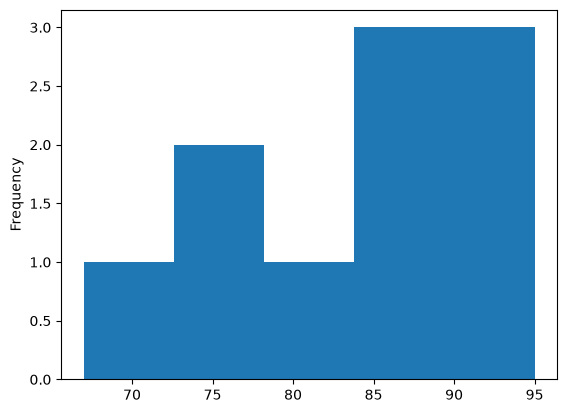

In [47]:
final_df["Marks"].plot(
    kind="hist",
    bins=5
)

plt.show()

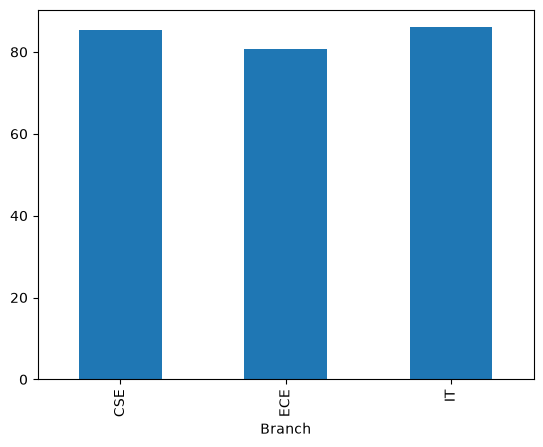

In [48]:
final_df.groupby(
    "Branch"
)["Marks"].mean().plot(
    kind="bar"
)

plt.show()

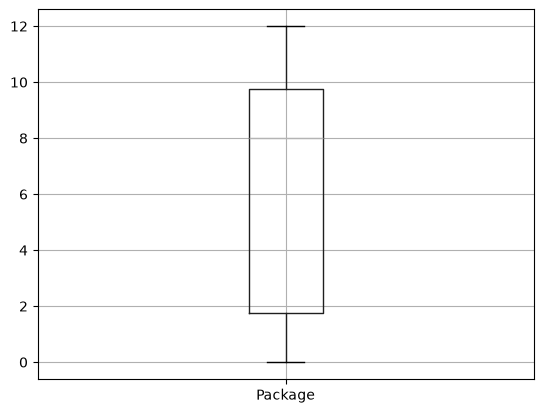

In [49]:
final_df.boxplot(
    column="Package"
)

plt.show()

In [51]:
insights = '''
1. CSE students have highest average marks.
2. Riya scored highest marks.
3. IT branch has highest placement percentage.
4. Average package is 6.5 LPA.
5. Students with attendance below 85% tend to score lower.
'''

In [54]:
with open('../reports/insights.txt', 'w') as file:
    file.write(insights)